In [2]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np


## univariate mae

In [3]:
df = pd.read_csv("jena_climate_2009_2016.csv")
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [4]:
df = df[5::6]
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.40,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.20,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.50,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.60,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.20,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420521,31.12.2016 19:10:00,1002.18,-0.98,272.01,-5.36,72.00,5.69,4.09,1.59,2.54,4.08,1280.70,0.87,1.36,190.6
420527,31.12.2016 20:10:00,1001.40,-1.40,271.66,-6.84,66.29,5.51,3.65,1.86,2.27,3.65,1281.87,1.02,1.92,225.4
420533,31.12.2016 21:10:00,1001.19,-2.75,270.32,-6.90,72.90,4.99,3.64,1.35,2.26,3.63,1288.02,0.71,1.56,158.7
420539,31.12.2016 22:10:00,1000.65,-2.89,270.22,-7.15,72.30,4.93,3.57,1.37,2.22,3.57,1288.03,0.35,0.68,216.7


In [5]:
df.index = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,,
2009-01-01 01:00:00,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
2009-01-01 02:00:00,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
2009-01-01 03:00:00,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
2009-01-01 04:00:00,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
2009-01-01 05:00:00,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


In [6]:
temp = df['T (degC)']
#temp.plot()

In [7]:
[[[]]]
def df_to_X_y(df , window_size = 5):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np) - window_size):
        row = [[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label = df_as_np[i+window_size]
        y.append(label)
    return np.array(X) , np.array(y)
        

In [8]:
x1, y1 = df_to_X_y(temp)
x1.shape, y1.shape

((70086, 5, 1), (70086,))

In [9]:
x_train, y_train = x1[:60000] , y1[:60000]
x_val , y_val = x1[60000:65000] , y1[60000:65000]
x_test , y_test = x1[65000:] , y1[65000:]
x_train.shape

(60000, 5, 1)

In [10]:
x_val.shape

(5000, 5, 1)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((5, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#cp1 = ModelCheckpoint('model1/', save_best_only=True)
model1.compile(loss=MeanAbsoluteError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [13]:
model1.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 4.9221 - root_mean_squared_error: 7.2520 - val_loss: 0.5832 - val_root_mean_squared_error: 0.8749
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.7028 - root_mean_squared_error: 1.1431 - val_loss: 0.5070 - val_root_mean_squared_error: 0.7454
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.5822 - root_mean_squared_error: 0.8911 - val_loss: 0.4908 - val_root_mean_squared_error: 0.7190
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.5560 - root_mean_squared_error: 0.8395 - val_loss: 0.4909 - val_root_mean_squared_error: 0.7134
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.5475 - root_mean_squared_error: 0.8233 - val_loss: 0.4942 - val_root_mean_squared_error: 0.7184
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.5492 - root_mean_squared_error: 0.8268 - val_loss: 0.4981 - val_root_mean_squared_error: 0.7183
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━

In [14]:
train_predictions = model1.predict(x_val)
test_predictions = model1.predict(x_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [15]:
train_predictions , y_val

(array([[15.82376 ],
        [13.401553],
        [13.127458],
        ...,
        [17.206064],
        [15.830477],
        [15.090233]], dtype=float32),
 array([14.02, 13.67, 12.27, ..., 16.65, 15.85, 15.09]))

In [16]:
test_predictions = model1.predict(x_test)

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


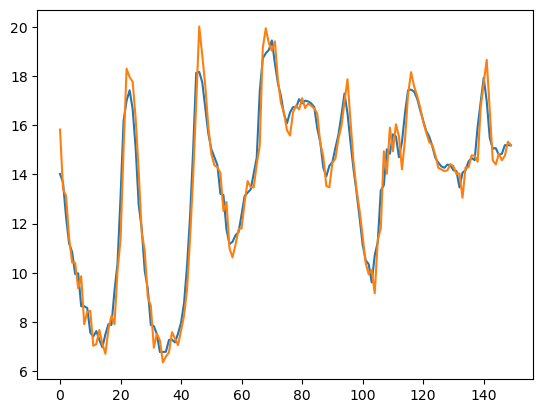

In [17]:
import matplotlib.pyplot as plt
plt.plot(y_val[:150])
plt.plot(train_predictions[:150])

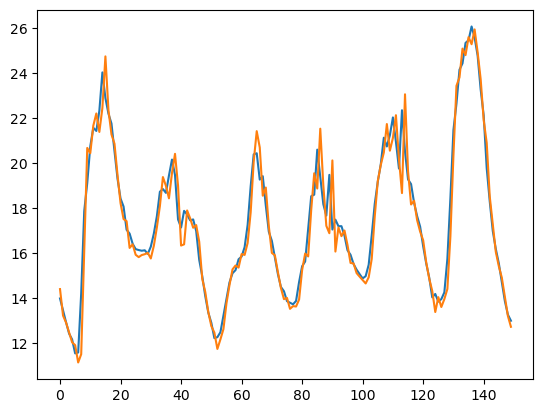

In [18]:
import matplotlib.pyplot as plt
plt.plot(y_test[:150])
plt.plot(test_predictions[:150])

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, test_predictions)
mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.5251175193548953
Mean Squared Error (MSE): 0.6026528912989497
Root Mean Squared Error (RMSE): 0.7763072145091463


In [20]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r2 = r2_score(y_test, test_predictions)

print("R-squared (R2) Score:", r2)


R-squared (R2) Score: 0.991343712487754


In [21]:
# Assuming `model` is your trained Keras model
model1.save('my_model1.h5')


In [22]:
from tensorflow.keras.models import load_model

# Load the model
loaded_model = load_model('my_model1.h5')

In [23]:
loaded_model

<Sequential name=sequential, built=True>

In [24]:
loaded_model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [25]:
model1.predict(x_test)

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[14.406027 ],
       [13.226768 ],
       [12.916935 ],
       ...,
       [-1.7490141],
       [-3.098646 ],
       [-3.1889126]], dtype=float32)

In [26]:
loaded_model.predict(x_test)

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([[14.406027 ],
       [13.226768 ],
       [12.916935 ],
       ...,
       [-1.7490141],
       [-3.098646 ],
       [-3.1889126]], dtype=float32)

## multivariate mse

In [28]:
temp_df = pd.DataFrame({'Temperature':temp})
temp_df['Seconds'] = temp_df.index.map(pd.Timestamp.timestamp)
temp_df

,Temperature,Seconds
Date Time,,
2009-01-01 01:00:00,-8.05,1.230772e+09
2009-01-01 02:00:00,-8.88,1.230775e+09
2009-01-01 03:00:00,-8.81,1.230779e+09
2009-01-01 04:00:00,-9.05,1.230782e+09
2009-01-01 05:00:00,-9.63,1.230786e+09
...,...,...
2016-12-31 19:10:00,-0.98,1.483211e+09
2016-12-31 20:10:00,-1.40,1.483215e+09
2016-12-31 21:10:00,-2.75,1.483219e+09


In [29]:
day = 60*60*24
year = 365.2425*day

temp_df['Day sin'] = np.sin(temp_df['Seconds'] * (2* np.pi / day))
temp_df['Day cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / day))
temp_df['Year sin'] = np.sin(temp_df['Seconds'] * (2 * np.pi / year))
temp_df['Year cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / year))
temp_df.head()

,Temperature,Seconds,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,
2009-01-01 01:00:00,-8.05,1.230772e+09,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,-8.88,1.230775e+09,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,-8.81,1.230779e+09,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,-9.05,1.230782e+09,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,-9.63,1.230786e+09,0.965926,0.258819,0.012916,0.999917


In [30]:
temp_df = temp_df.drop('Seconds', axis=1)
temp_df.head()


,Temperature,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,
2009-01-01 01:00:00,-8.05,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,-8.88,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,-8.81,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,-9.05,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,-9.63,0.965926,0.258819,0.012916,0.999917


In [31]:
p_temp_df = pd.concat([df['p (mbar)'], temp_df], axis=1)
p_temp_df.head()

,p (mbar),Temperature,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,
2009-01-01 01:00:00,996.50,-8.05,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,0.965926,0.258819,0.012916,0.999917


In [32]:
def df_to_X_y2(df, window_size=7):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][1]
    y.append(label)
  return np.array(X), np.array(y)

In [33]:
X2, y2 = df_to_X_y2(p_temp_df)
X2.shape, y2.shape

((70084, 7, 6), (70084,))

In [34]:
X2_train, y2_train = X2[:60000], y2[:60000]
X2_val, y2_val = X2[60000:65000], y2[60000:65000]
X2_test, y2_test = X2[65000:], y2[65000:]
X2_train.shape, y2_train.shape, X2_val.shape, y2_val.shape, X2_test.shape, y2_test.shape

((60000, 7, 6), (60000,), (5000, 7, 6), (5000,), (5084, 7, 6), (5084,))

In [35]:
p_training_mean2 = np.mean(X2_train[:, :, 0])
p_training_std2 = np.std(X2_train[:, :, 0])

temp_training_mean2 = np.mean(X2_train[:, :, 1])
temp_training_std2 = np.std(X2_train[:, :, 1])

def preprocess2(X):
  X[:, :, 0] = (X[:, :, 0] - p_training_mean2) / p_training_std2
  X[:, :, 1] = (X[:, :, 1] - temp_training_mean2) / temp_training_std2

In [36]:
preprocess2(X2_train)
preprocess2(X2_val)
preprocess2(X2_test)


In [37]:
def preprocess_output2(y):
  
  y = (y - temp_training_mean2) / temp_training_std2
  return y

In [38]:
preprocess_output2(y2_train)
preprocess_output2(y2_val)
preprocess_output2(y2_test)

array([ 0.41245076,  0.35368268,  0.32312327, ..., -1.43051636,
       -1.44697142, -1.56920903])

In [39]:
model2 = Sequential()
model2.add(InputLayer((7, 6)))
model2.add(LSTM(64))
model2.add(Dense(8, 'relu'))
model2.add(Dense(1, 'linear'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,705 (73.07 KB)

 Trainable params: 18,705 (73.07 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [41]:
model2.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 69.0847 - root_mean_squared_error: 7.9921 - val_loss: 3.8480 - val_root_mean_squared_error: 1.9616
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 4.8379 - root_mean_squared_error: 2.1953 - val_loss: 2.0046 - val_root_mean_squared_error: 1.4159
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 2.0461 - root_mean_squared_error: 1.4277 - val_loss: 1.1596 - val_root_mean_squared_error: 1.0768
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 1.1064 - root_mean_squared_error: 1.0514 - val_loss: 0.6967 - val_root_mean_squared_error: 0.8347
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.7697 - root_mean_squared_error: 0.8771 - val_loss: 0.5149 - val_root_mean_squared_error: 0.7176
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.6065 - root_mean_squared_error: 0.7788 - val_loss: 0.4609 - val_root_mean_squared_error: 0.6789
Epoch 7/50
1875/1875 ━━━━━━━━━━━

In [42]:
y2_pred = model2.predict(X2_test)
y2_pred

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([[12.899319 ],
       [12.457892 ],
       [12.051927 ],
       ...,
       [-1.5749454],
       [-3.0264926],
       [-2.9893088]], dtype=float32)

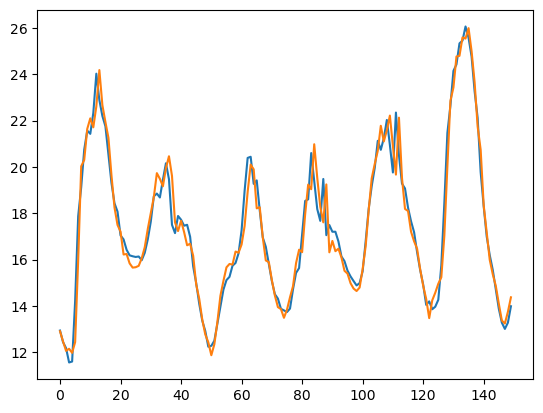

In [43]:
import matplotlib.pyplot as plt
plt.plot(y2_test[:150])
plt.plot(y2_pred[:150])

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y2_test, y2_pred)
mse = mean_squared_error(y2_test, y2_pred)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.4613435495857012
Mean Squared Error (MSE): 0.44679710312438
Root Mean Squared Error (RMSE): 0.6684288317572634


In [45]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r2 = r2_score(y2_test, y2_pred)

print("R-squared (R2) Score:", r2)


R-squared (R2) Score: 0.9935848499552197


In [46]:
model2.save('my_model2_multivariate.h5')

In [47]:
loaded_model = load_model('my_model2_multivariate.h5')

In [48]:
loaded_model.predict(X2_test)

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([[12.899319 ],
       [12.457892 ],
       [12.051927 ],
       ...,
       [-1.5749454],
       [-3.0264926],
       [-2.9893088]], dtype=float32)

## univariate mse

In [122]:
model3 = Sequential()
model3.add(InputLayer((5, 1)))
model3.add(LSTM(64))
model3.add(Dense(8, 'relu'))
model3.add(Dense(1, 'linear'))

model3.summary()
model3.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0003), metrics=[RootMeanSquaredError()])
model3.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=50)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 33.3405 - root_mean_squared_error: 5.3867 - val_loss: 0.5739 - val_root_mean_squared_error: 0.7576
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.8180 - root_mean_squared_error: 0.9039 - val_loss: 0.5128 - val_root_mean_squared_error: 0.7161
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6842 - root_mean_squared_error: 0.8272 - val_loss: 0.5056 - val_root_mean_squared_error: 0.7111
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6674 - root_mean_squared_error: 0.8168 - val_loss: 0.4929 - val_root_mean_squared_error: 0.7021
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6480 - root_mean_squared_error: 0.8049 - val_loss: 0.5436 - val_root_mean_squared_error: 0.7373
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6491 - root_mean_squared_error: 0.8056 - val_loss: 0.4877 - val_root_mean_squared_error: 0.6984
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


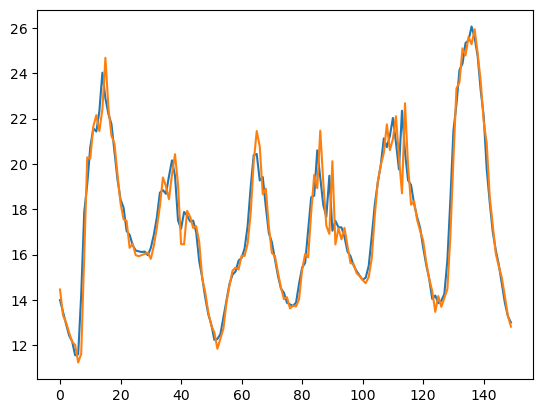

In [123]:
test_predictions_ = model3.predict(x_test)
import matplotlib.pyplot as plt
plt.plot(y_test[:150])
plt.plot(test_predictions_[:150])

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, test_predictions_)
mse = mean_squared_error(y_test, test_predictions_)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.5212095477836037
Mean Squared Error (MSE): 0.5865457255667925
Root Mean Squared Error (RMSE): 0.7658627328489045


In [125]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r3 = r2_score(y_test, test_predictions_)

print("R-squared (R2) Score:", r3)

R-squared (R2) Score: 0.9915750699732949


## univariate huber loss

In [132]:
from tensorflow.keras.losses import Huber
model4 = Sequential()
model4.add(InputLayer((5, 1)))
model4.add(LSTM(64))
model4.add(Dense(8, 'relu'))
model4.add(Dense(1, 'linear'))

model4.summary()
model4.compile(loss=Huber(delta= 1.0), optimizer=Adam(learning_rate=0.0003), metrics=[RootMeanSquaredError()])
model4.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=50)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 3.7181 - root_mean_squared_error: 6.5577 - val_loss: 0.2172 - val_root_mean_squared_error: 0.7260
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.2820 - root_mean_squared_error: 0.8778 - val_loss: 0.2067 - val_root_mean_squared_error: 0.7038
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2598 - root_mean_squared_error: 0.8180 - val_loss: 0.2069 - val_root_mean_squared_error: 0.7057
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2543 - root_mean_squared_error: 0.8074 - val_loss: 0.2138 - val_root_mean_squared_error: 0.7174
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2549 - root_mean_squared_error: 0.8070 - val_loss: 0.2053 - val_root_mean_squared_error: 0.7022
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2525 - root_mean_squared_error: 0.8052 - val_loss: 0.2027 - val_root_mean_squared_error: 0.6968
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


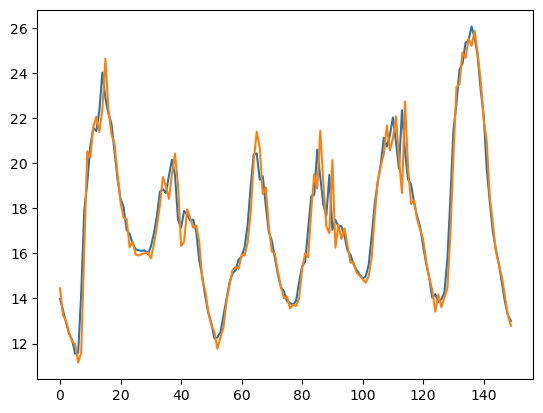

In [133]:
test_predictions__ = model4.predict(x_test)
import matplotlib.pyplot as plt
plt.plot(y_test[:150])
plt.plot(test_predictions__[:150])

In [134]:
mae = mean_absolute_error(y_test, test_predictions__)
mse = mean_squared_error(y_test, test_predictions__)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.522955046402883
Mean Squared Error (MSE): 0.591143476814674
Root Mean Squared Error (RMSE): 0.7688585544914448


In [135]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r4 = r2_score(y_test, test_predictions_)

print("R-squared (R2) Score:", r4)

R-squared (R2) Score: 0.9915750699732949


In [140]:
model3.save('my_model_univariate_mse.h5')
model4.save('my_model_univariate_huber_loss.h5')

## multivariate mae

In [147]:
model5 = Sequential()
model5.add(InputLayer((7, 6)))
model5.add(LSTM(64))
model5.add(Dense(8, 'relu'))
model5.add(Dense(1, 'linear'))
model5.compile(loss=MeanAbsoluteError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])
model5.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 6.2227 - root_mean_squared_error: 8.5181 - val_loss: 1.3855 - val_root_mean_squared_error: 1.8352
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1.4888 - root_mean_squared_error: 2.0787 - val_loss: 1.0361 - val_root_mean_squared_error: 1.3582
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1.0236 - root_mean_squared_error: 1.4421 - val_loss: 0.7464 - val_root_mean_squared_error: 1.0004
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.7676 - root_mean_squared_error: 1.0955 - val_loss: 0.6423 - val_root_mean_squared_error: 0.8777
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.6562 - root_mean_squared_error: 0.9443 - val_loss: 0.5514 - val_root_mean_squared_error: 0.7663
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.5826 - root_mean_squared_error: 0.8413 - val_loss: 0.5113 - val_root_mean_squared_error: 0.7188
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


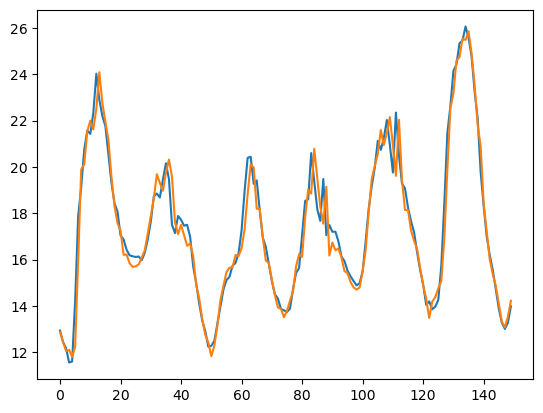

In [148]:
y2_pred_ = model5.predict(X2_test)
import matplotlib.pyplot as plt
plt.plot(y2_test[:150])
plt.plot(y2_pred_[:150])

In [149]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y2_test, y2_pred_)
mse = mean_squared_error(y2_test, y2_pred_)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.4557587315300428
Mean Squared Error (MSE): 0.45060931686848454
Root Mean Squared Error (RMSE): 0.6712743975964557


In [1]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r5 = r2_score(y2_test, y2_pred_)

print("R-squared (R2) Score:", r5)


NameError: name 'y2_test' is not defined

## multivariate  huber loss

In [156]:
model6 = Sequential()
model6.add(InputLayer((7, 6)))
model6.add(LSTM(64))
model6.add(Dense(8, 'relu'))
model6.add(Dense(1, 'linear'))
model6.compile(loss=Huber(delta = 1.0), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])
model6.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 6.2815 - root_mean_squared_error: 9.0038 - val_loss: 0.9820 - val_root_mean_squared_error: 1.8522
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1.1180 - root_mean_squared_error: 2.1510 - val_loss: 0.5800 - val_root_mean_squared_error: 1.2752
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.5881 - root_mean_squared_error: 1.3535 - val_loss: 0.3279 - val_root_mean_squared_error: 0.9012
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3638 - root_mean_squared_error: 0.9935 - val_loss: 0.2501 - val_root_mean_squared_error: 0.7693
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2734 - root_mean_squared_error: 0.8339 - val_loss: 0.2109 - val_root_mean_squared_error: 0.7014
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2331 - root_mean_squared_error: 0.7645 - val_loss: 0.1877 - val_root_mean_squared_error: 0.6594
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


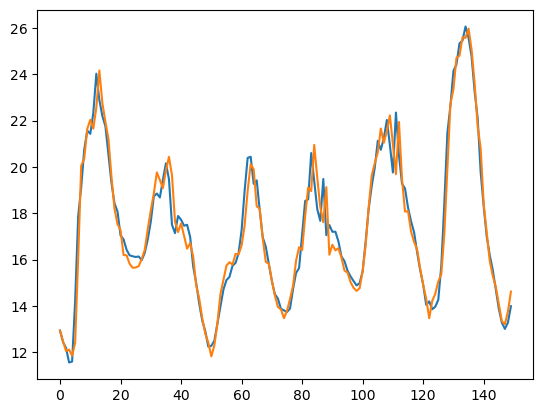

In [157]:
y2_pred__ = model6.predict(X2_test)
import matplotlib.pyplot as plt
plt.plot(y2_test[:150])
plt.plot(y2_pred__[:150])

In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y2_test, y2_pred__)
mse = mean_squared_error(y2_test, y2_pred__)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.45818937378415997
Mean Squared Error (MSE): 0.4408956790132395
Root Mean Squared Error (RMSE): 0.663999758293058


In [5]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r6 = r2_score(y2_test, y2_pred)

print("R-squared (R2) Score:", r6)


NameError: name 'y2_test' is not defined

In [166]:
model5.save('my_model_multivariate_mae.h5')
model6.save('my_model_multivariate_huber_loss.h5')

In [168]:
model3.save('my_model_univariate_mse.h5')
model4.save('my_model_univariate_huber_loss.h5')